In [16]:
import os, pandas as pd, json, glob
from tqdm import tqdm
from openai import OpenAI
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

client = OpenAI()

In [23]:
# Function to load gold dataset and extract character set
def load_gold_data(file_path):
    gold_data = pd.read_excel(file_path, sheet_name="ALL INSTANCES")
    return gold_data

# Function to process a single prompt
def process_prompt(prompt, model = "gpt-4o-mini"):
    response = client.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": prompt}],
        response_format={"type": "json_object"}
    )
    return response.choices[0].message.content

# Function to split text into chunks
def split_text(text, max_tokens = 1000):
    paragraphs = text.split("\n\n")
    chunks = []
    current_chunk = ""
    for paragraph in paragraphs:
        if len(current_chunk) + len(paragraph) <= max_tokens:
            current_chunk += paragraph + "\n\n"
        else:
            chunks.append(current_chunk.strip())
            current_chunk = paragraph
    if current_chunk:
        chunks.append(current_chunk.strip())
    return chunks

# Approach 1: Whole Chapter, All Tags
def tag_whole_chapter(chapter_text, character_set):
    prompt = f"""
    You are an expert in literary analysis. Please analyze the following text and tag all instances of the following characters if they appear in the given chapter:
    {', '.join(character_set)}

    For each character, include all name variants under the normalized form above (e.g., tags for "Lizzy" should be counted under "Elizabeth")

    For each character, provide the following tags:
    - N: Count all named mentions of this person (including variants).
    - A: Count each verb of physical action (exclude speech, thought, and feeling verbs).
    - C: Count blocks of directly quoted dialogue, paraphrased speech, and letters.
    - I: Count each verb expressing thought, feeling, intention, or interpretation.
    - DN: Count sentences describing the character by the narrator.
    - DC: Count sentences where other characters discuss the character.

    Text:
    {chapter_text}

    Return the results as a JSON object with each character as a key and their tags as values. Only include characters that have at least one non-zero tag.
    If a character has all tags equal to zero, omit it from the JSON output entirely.
    
    Strictly output JSON in this format:
    {{
        "Character1": {{"N": count1, "A": countA1, "C": countC1, "I": countI1, "DN": countDN1, "DC": countDC1}},
        "Character2": {{"N": count2, "A": countA2, "C": countC2, "I": countI2, "DN": countDN2, "DC": countDC2}},
        ...
    }}
    """
    response = process_prompt(prompt)
    return json.loads(response)

# Approach 2: Chunk Chapter, All Tags
def tag_chunked_chapter(chapter_text, character_set, max_tokens = 1000):
    '''Process a chapter in chunks and aggregate results.'''
    
    chunks = split_text(chapter_text, max_tokens)
    chunk_results = []
    for i, chunk in enumerate(chunks):
        print(f"Processing Chunk {i+1}...")
        prompt = f"""
        You are an expert in literary analysis. Please analyze the following text and tag all instances of the following characters:
        {', '.join(character_set)}

        For each character, include all name variants under the normalized form above (e.g., tags for "Lizzy" should be counted under "Elizabeth")

        For each character, provide the following tags:
        - N: Count all name mentions (including variants).
        - A: Count each verb of physical action (exclude speech, thought, and feeling verbs).
        - C: Count blocks of directly quoted dialogue, paraphrased speech, and letters.
        - I: Count each verb expressing thought, feeling, intention, or interpretation.
        - DN: Count sentences describing the character by the narrator.
        - DC: Count sentences where other characters discuss the character.

        Text:
        {chunk}

        Return the results as a JSON object with each character as a key and their tags as values. Only include characters that have at least one non-zero tag.
        If a character has all tags equal to zero, omit it from the JSON output entirely.
        
        Strictly output JSON in this format:
        {{
            "Character1": {{"N": count1, "A": countA1, "C": countC1, "I": countI1, "DN": countDN1, "DC": countDC1}},
            "Character2": {{"N": count2, "A": countA2, "C": countC2, "I": countI2, "DN": countDN2, "DC": countDC2}},
            ...
        }}
        """
        response = process_prompt(prompt)
        chunk_results.append(json.loads(response))
    
    # Sum results across chunks (robust to missing tags)
    combined_results = {}
    for chunk_result in chunk_results:
        for character, tags in chunk_result.items():
            if character not in combined_results:
                combined_results[character] = {}
            for tag, cnt in tags.items():
                combined_results[character][tag] = combined_results[character].get(tag, 0) + cnt

    # Ensure all six tags exist for every character
    expected_tags = ["N", "A", "C", "I", "DN", "DC"]
    for char in combined_results:
        for t in expected_tags:
            combined_results[char].setdefault(t, 0)
    return combined_results
    
# Approach 3: Whole Chapter, One Tag at a Time
def tag_whole_chapter_one_tag(chapter_text, character_set, tag):
    descriptions = {"N": "Count all name mentions (including variants).",
                    "A": "Count each verb of physical action (exclude speech, thought, and feeling verbs).",
                    "C": "Count blocks of directly quoted dialogue, paraphrased speech, and letters.",
                    "I": "Count each verb expressing thought, feeling, intention, or interpretation.",
                    "DN": "Count sentences describing the character by the narrator.",
                    "DC": "Count sentences where other characters discuss the character."
                    }
    
    prompt = f"""
    You are an expert in literary analysis. Please analyze the following text and tag all instances of the following characters:
    {', '.join(character_set)}

    For each character, include all name variants under the normalized form above (e.g., tags for "Lizzy" should be counted under "Elizabeth")
    
    Provide the counts for the tag '{tag}' only.
    
    The tag '{tag}' is defined as:
    - {descriptions[tag]}
    
    Text:
    {chapter_text}

    Return the results as a JSON object with each character as a key and its '{tag}' tag as value. Only include characters that have a non-zero count.
    If a character has '{tag}' tag count equal to zero, omit it from the JSON output entirely.
    
    Strictly output JSON in this format:
    {{
        "Character1": {{{tag}: count1}},
        "Character2": {{{tag}: count2}},
        ...
    }}
    """
    response = process_prompt(prompt)
    return json.loads(response)

def tag_whole_chapter_all_tags_separately(chapter_text, character_set):
    tags = ["N", "A", "C", "I", "DN", "DC"]
    combined_results = {}
    for tag in tags:
        print(f"Processing Tag: {tag}")
        tag_results = tag_whole_chapter_one_tag(chapter_text, character_set, tag)
        for character, count in tag_results.items():
            if character not in combined_results:
                combined_results[character] = {t: 0 for t in tags}
            combined_results[character][tag] = count
    return combined_results

SyntaxError: unterminated string literal (detected at line 122) (1524421078.py, line 122)

In [22]:
# Load gold dataset
gold_data = load_gold_data("data/manual/pride_and_prejudice.xlsx")
character_set = gold_data['Character'].unique().tolist()

chapter_dir = "data/chapters/"
# Load chapters (example: list of chapter texts)
chapters = []
for chapter_file in sorted(glob.glob(os.path.join(chapter_dir, "pride_and_prejudice_*.txt"))):
    with open(chapter_file, 'r') as f:
        chapter_text = f.read()
        chapters.append(chapter_text)
all_results = []

for i, chapter_text in enumerate(chapters):
    print(f"Processing Chapter {i+1}...")

    # Run all three approaches
    whole = tag_whole_chapter(chapter_text, character_set)
    chunked = tag_chunked_chapter(chapter_text, character_set)
    separate = tag_whole_chapter_all_tags_separately(chapter_text, character_set)

    for method_name, results in [("whole", whole), ("chunked", chunked), ("separate", separate)]:
        for character, tags in results.items():
            for tag, count in tags.items():
                all_results.append({
                    "chapter": i + 1,
                    "method": method_name,
                    "character": character,
                    "tag": tag,
                    "count": count
                })

results_df = pd.DataFrame(all_results)
results_df.to_csv(f"results/model_results_all_chapters_{datetime.now().strftime('%H%M')}.csv", index=False)

Processing Chapter 1...


KeyboardInterrupt: 

Tag-level summary (across all characters and chapters):
      method tag  mean_abs_error  mean_pct_error  corr
0    chunked   A        2.456067        0.969264   NaN
1    chunked   C        1.944290        0.950256   NaN
2    chunked  DC        4.966574        0.956338   NaN
3    chunked  DN        0.615599        0.885747   NaN
4    chunked   I        2.711699        0.961968   NaN
5    chunked   N        3.993036        0.925373   NaN
6   separate   A        2.727882        1.117795   NaN
7   separate   C        2.401606        0.983110   NaN
8   separate  DC        4.665328        1.051111   NaN
9   separate  DN        1.579652        1.411853   NaN
10  separate   I        2.811245        1.028003   NaN
11  separate   N        3.555556        1.071536   NaN
12     whole   A        2.361930        0.944168   NaN
13     whole   C        1.925033        0.813133   NaN
14     whole  DC        4.477912        0.907462   NaN
15     whole  DN        1.082999        1.070278   NaN
16     wh

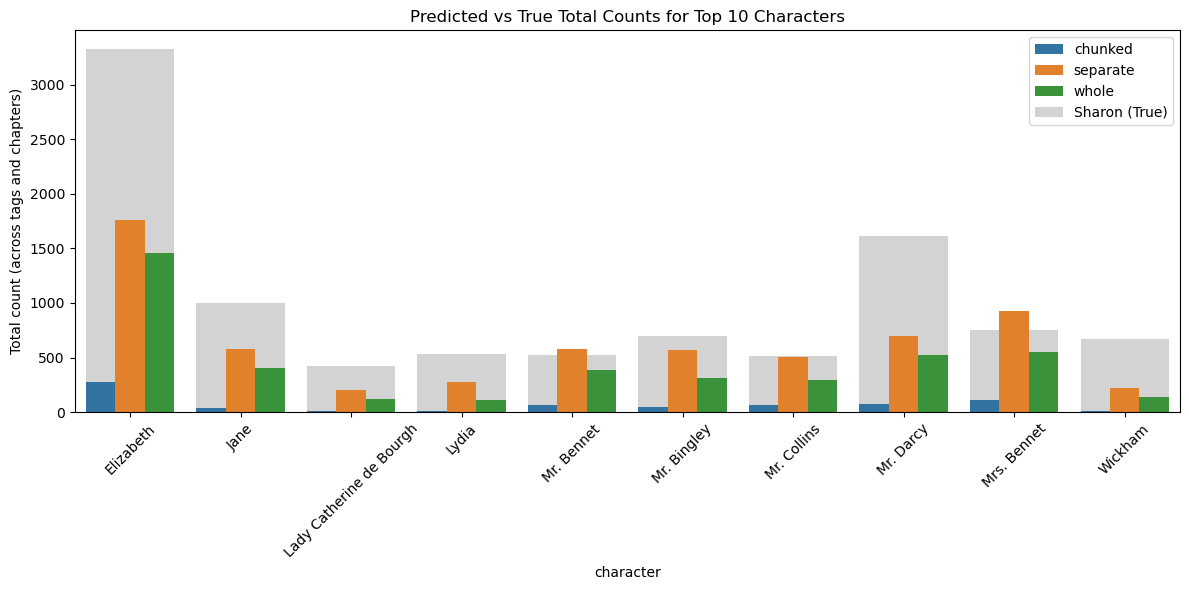

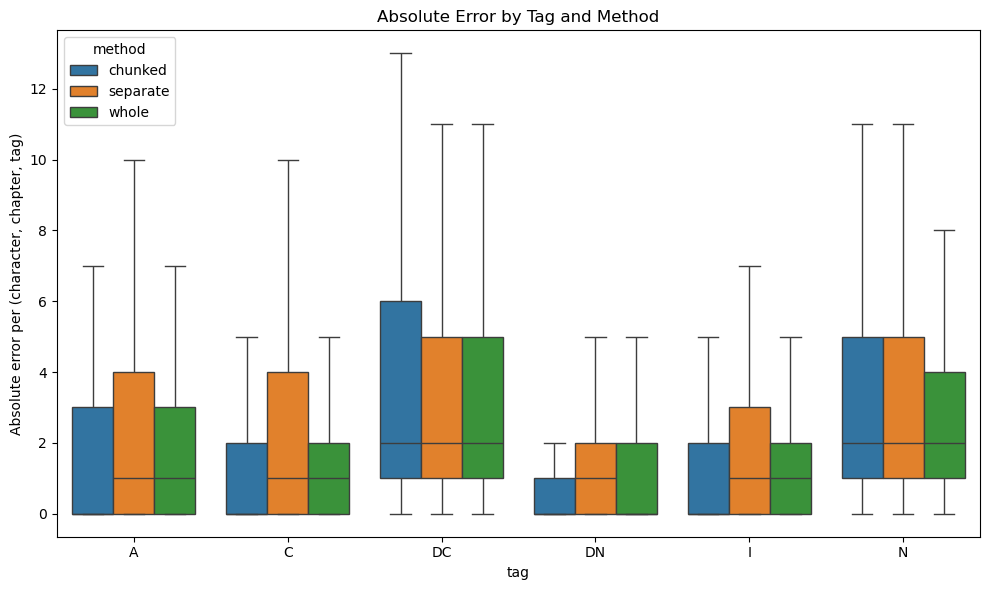

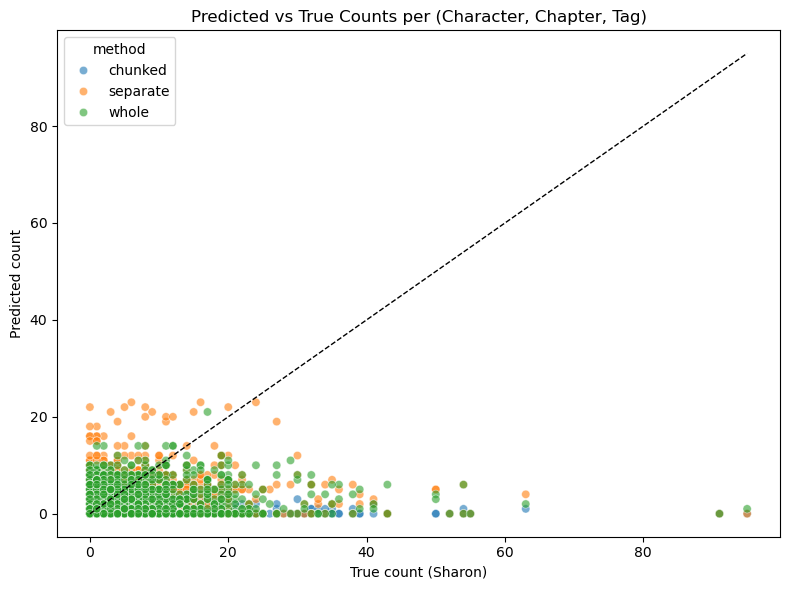

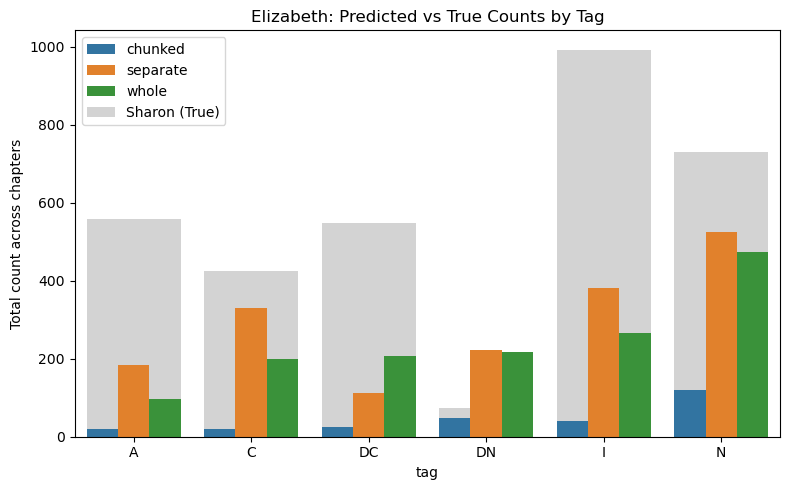

In [12]:
results_df = pd.read_csv("results/model_results_all_chapters.csv")
results_df["count"] = pd.to_numeric(results_df["count"], errors="coerce")


# Prepare gold data (true counts)
gold_long = (
    gold_data.melt(
        id_vars=["Character", "Chapter"],
        value_vars=["N", "A", "C", "I", "DN", "DC"],
        var_name="tag",
        value_name="true_count"
    )
    .rename(columns={"Character": "character", "Chapter": "chapter"})
)

# Aggregate model outputs
agg_model = (
    results_df.groupby(["method", "chapter", "character", "tag"])["count"]
    .sum()
    .reset_index()
)

# Merge model predictions with gold ground truth (align by chapter)
merged = agg_model.merge(gold_long, on=["character", "tag", "chapter"], how="inner")

# Compute errors
merged["error"] = merged["count"] - merged["true_count"]
merged["abs_error"] = merged["error"].abs()
merged["pct_error"] = merged["abs_error"] / merged["true_count"].replace(0, np.nan)

summary = (
    merged.groupby(["method", "tag"])
    .agg(
        mean_abs_error=("abs_error", "mean"),
        mean_pct_error=("pct_error", "mean"),
        corr=("count", lambda x: np.corrcoef(x, merged.loc[x.index, "true_count"])[0, 1])
    )
    .reset_index()
)

print("Tag-level summary (across all characters and chapters):")
print(summary.sort_values("corr", ascending=False))

overall_corr = (
    merged.groupby("method")[["count", "true_count"]]
    .corr()
    .iloc[0::2, -1]
    .reset_index()
    .rename(columns={"true_count": "overall_corr"})
)
print("\nOverall correlation by method:")
print(overall_corr)

# Character-level evaluation
char_summary = (
    merged.groupby(["method", "character"])
    .agg(
        mae=("abs_error", "mean"),
        total_true=("true_count", "sum"),
        total_pred=("count", "sum")
    )
    .reset_index()
)

# Top 10 characters by gold frequency
top_chars = (
    gold_long.groupby("character")["true_count"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index.tolist()
)
print("\nTop 10 characters by true frequency:")
print(top_chars)

# Top characters aggregated across chapters and tags
subset = merged[merged["character"].isin(top_chars)]
plot_df = (
    subset.groupby(["character", "method"])[["count"]].sum().reset_index()
)
true_totals = (
    gold_long[gold_long["character"].isin(top_chars)]
    .groupby("character")[["true_count"]].sum().reset_index()
)

plt.figure(figsize=(12, 6))
sns.barplot(data=true_totals, x="character", y="true_count",
            color="lightgray", label="gold (True)", errorbar=None)
sns.barplot(data=plot_df, x="character", y="count",
            hue="method", errorbar=None)
plt.xticks(rotation=45)
plt.ylabel("Total count (across tags and chapters)")
plt.title("Predicted vs True Total Counts for Top 10 Characters")
plt.legend()
plt.tight_layout()
plt.show()

# Tag-level absolute error (no outlier distortion)
plt.figure(figsize=(10, 6))
sns.boxplot(data=merged, x="tag", y="abs_error", hue="method", showfliers=False)
plt.title("Absolute Error by Tag and Method")
plt.ylabel("Absolute error per (character, chapter, tag)")
plt.tight_layout()
plt.show()

# Predicted vs True counts (scatter)
plt.figure(figsize=(8, 6))
sns.scatterplot(data=merged, x="true_count", y="count",
                hue="method", alpha=0.6)
max_val = max(merged["true_count"].max(), merged["count"].max())
plt.plot([0, max_val], [0, max_val], "k--", lw=1)
plt.xlabel("True count (gold)")
plt.ylabel("Predicted count")
plt.title("Predicted vs True Counts per (Character, Chapter, Tag)")
plt.tight_layout()
plt.show()

# Focused analysis: Elizabeth
elizabeth_df = merged[merged["character"].str.contains("Elizabeth", case=False)]
el_tag = (
    elizabeth_df.groupby(["tag", "method"])[["count"]].sum().reset_index()
)
el_true = (
    gold_long[gold_long["character"].str.contains("Elizabeth", case=False)]
    .groupby("tag")[["true_count"]].sum().reset_index()
)

plt.figure(figsize=(8, 5))
sns.barplot(data=el_true, x="tag", y="true_count",
            color="lightgray", label="gold (True)", errorbar=None)
sns.barplot(data=el_tag, x="tag", y="count",
            hue="method", errorbar=None)
plt.title("Elizabeth: Predicted vs True Counts by Tag")
plt.ylabel("Total count across chapters")
plt.legend()
plt.tight_layout()
plt.show()